# 05 — EDA: what actually correlates with price (Sefton, first pass)

Plan Part 1 built a table of "what drives price" from the **King County**
(Seattle) reference dataset, because that's what we had before any UK data
existed. Now that Sefton is joined and cleaned, this notebook does the real
version: pull in the EPC fields we haven't used yet (energy rating, tenure,
construction age, glazing, heating type, ...) and check what actually
correlates with price **in our own data**, not by analogy.

This is a first pass on Sefton alone — re-run once the other five local
authorities are added (Phase 2), but the fields that show nothing here are
unlikely to suddenly matter with more rows of the same kind of housing
stock, so it's a reasonable early filter.

**How to read this notebook if you're new to this:** "correlation" is a
number from -1 to +1 that says how strongly two things move together.
Near 0 means "no relationship visible." Positive means "as this goes up,
price tends to go up too." Negative means the opposite. It only catches
straight-line relationships — a few things below need a different check
(grouping by category and comparing average price) because they're not
numbers on a line, they're categories like "detached" or "leasehold."


In [1]:
import sys
sys.path.insert(0, "..")
from src.config import DATA_RAW, DATA_INTERIM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

joined = pd.read_parquet(DATA_INTERIM / "ppd_epc_joined_sefton.parquet")
print(f"{len(joined):,} joined transactions")


61,344 joined transactions


## Pull in the fields notebook 02 didn't keep

Notebook 02 kept a lean set of columns for the join. This EDA pass reads
the raw EPC file fresh with a wider set — energy rating and score, tenure,
construction age, heating and glazing details — since the whole point here
is finding out which of them matter before deciding what's worth carrying
into Phase 2's feature set.


In [2]:
WIDE_COLS = [
    "uprn", "postcode", "address1",
    "property_type", "built_form", "construction_age_band", "tenure",
    "total_floor_area", "number_habitable_rooms", "number_heated_rooms",
    "extension_count", "number_open_fireplaces",
    "current_energy_efficiency", "current_energy_rating",
    "potential_energy_efficiency", "potential_energy_rating",
    "co2_emissions_current",
    "main_fuel", "mains_gas_flag",
    "glazed_type", "multi_glaze_proportion",
    "mainheat_description", "mainheat_energy_eff",
    "walls_energy_eff", "roof_energy_eff", "windows_energy_eff",
    "inspection_date",
]

epc_wide = pd.read_csv(
    DATA_RAW / "epc" / "sefton_certificates.csv",
    usecols=WIDE_COLS, dtype=str, low_memory=False,
)
epc_wide["uprn"] = pd.to_numeric(epc_wide["uprn"], errors="coerce")
epc_wide["total_floor_area"] = pd.to_numeric(epc_wide["total_floor_area"], errors="coerce")
epc_wide["inspection_date"] = pd.to_datetime(epc_wide["inspection_date"], errors="coerce")
for col in ["current_energy_efficiency", "potential_energy_efficiency", "co2_emissions_current",
            "number_habitable_rooms", "number_heated_rooms", "extension_count",
            "number_open_fireplaces", "multi_glaze_proportion"]:
    epc_wide[col] = pd.to_numeric(epc_wide[col], errors="coerce")

print(f"{len(epc_wide):,} certificates with the wider field set loaded")


116,521 certificates with the wider field set loaded


## Pick the certificate current as of each sale date

Same logic as notebook 03b: a property can have several EPCs over time
(26.1% do), and using one issued *after* the sale would leak information
about renovations the buyer made — the model would be cheating by knowing
the future. Group by UPRN once for a fast lookup rather than rescanning the
whole table per transaction.


In [3]:
epc_sorted = epc_wide.dropna(subset=["uprn"]).sort_values("inspection_date")
epc_groups = {uprn: grp for uprn, grp in epc_sorted.groupby("uprn")}

def certificate_as_of(uprn, sale_date):
    candidates = epc_groups.get(uprn)
    if candidates is None:
        return None
    valid = candidates[candidates["inspection_date"] <= sale_date]
    if valid.empty:
        return candidates.iloc[0]
    return valid.iloc[-1]

rows = []
for row in joined.dropna(subset=["uprn_final"]).itertuples(index=False):
    cert = certificate_as_of(row.uprn_final, row.date_of_transfer)
    if cert is None:
        continue
    d = cert.to_dict()
    d["price"] = row.price
    d["date_of_transfer"] = row.date_of_transfer
    d["transaction_id"] = row.transaction_id
    rows.append(d)

df = pd.DataFrame(rows)
df["log_price"] = np.log(df["price"])
print(f"{len(df):,} transactions with full EPC detail attached")


52,976 transactions with full EPC detail attached


## Numeric fields: correlation with price

The straightforward check first. `log_price` is used rather than raw price
for the same reason as the Phase 1 baseline: price differences matter
proportionally (an extra £20k means a lot more on a £100k house than a
£500k one), and log turns that into a straight-line relationship a
correlation number can actually capture.


In [4]:
numeric_cols = [
    "total_floor_area", "number_habitable_rooms", "number_heated_rooms",
    "extension_count", "number_open_fireplaces",
    "current_energy_efficiency", "potential_energy_efficiency",
    "co2_emissions_current", "multi_glaze_proportion",
]

corrs = df[numeric_cols + ["log_price"]].corr()["log_price"].drop("log_price").sort_values(key=abs, ascending=False)
print("Correlation with log(price):\n")
for field, val in corrs.items():
    bar = "#" * int(abs(val) * 40)
    print(f"{field:32s} {val:+.3f}  {bar}")


Correlation with log(price):

number_heated_rooms              +0.603  ########################
number_habitable_rooms           +0.582  #######################
total_floor_area                 +0.551  ######################
co2_emissions_current            +0.315  ############
extension_count                  +0.237  #########
number_open_fireplaces           +0.114  ####
current_energy_efficiency        +0.069  ##
potential_energy_efficiency      -0.033  #
multi_glaze_proportion           -0.003  


## The full correlation matrix

Same idea as the King County matrix from the plan, but for our own Sefton
data: every field plotted against every other field, not just against
price. Dark red = strong positive relationship (both go up together), dark
blue = strong negative (one goes up as the other goes down), pale = little
relationship visible. `price` is the row/column to scan for the headline
answer, but the off-diagonal cells are worth a look too — e.g. do floor
area and room count move together so closely that keeping both as separate
features would be redundant?


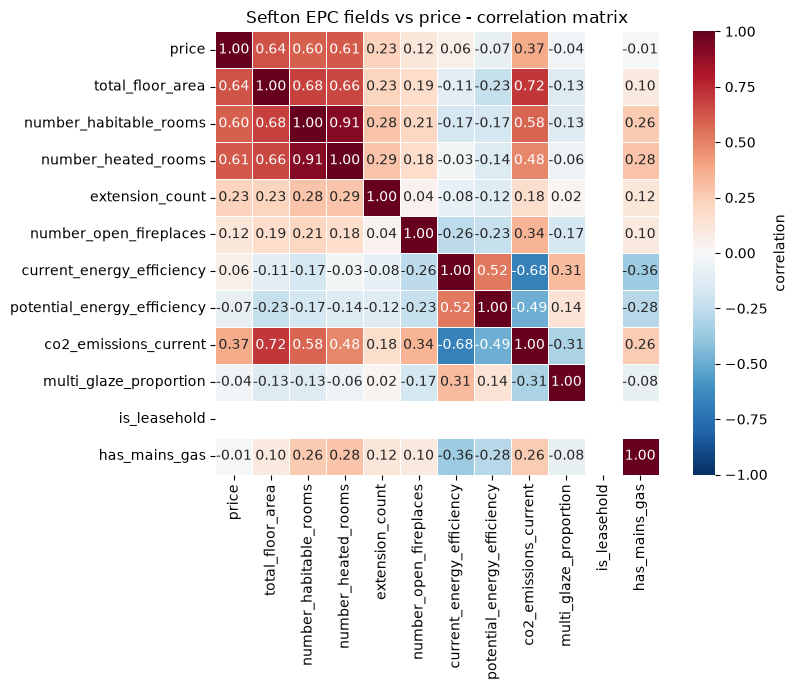

In [5]:
# Fold in two categorical fields as yes/no flags, the way King County's
# `waterfront` (0/1) sat alongside its numeric fields in the same matrix.
df["is_leasehold"] = (df["tenure"].str.contains("leasehold", case=False, na=False)).astype(int)
df["has_mains_gas"] = (df["mains_gas_flag"] == "Y").astype(int)

matrix_cols = ["price"] + numeric_cols + ["is_leasehold", "has_mains_gas"]
corr_matrix = df[matrix_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
    center=0, square=True, linewidths=0.5, cbar_kws={"label": "correlation"},
    ax=ax,
)
ax.set_title("Sefton EPC fields vs price - correlation matrix")
plt.tight_layout()
plt.show()


## Categorical fields: does the average price differ by group?

Correlation doesn't apply to things like "detached vs terraced" — there's
no numeric order to a category. Instead, compare the median price in each
group. A field is worth keeping as a feature if the groups clearly differ;
if they're all roughly the same, it's not carrying much information.


In [6]:
categorical_cols = [
    "property_type", "built_form", "tenure", "construction_age_band",
    "current_energy_rating", "main_fuel", "mains_gas_flag", "glazed_type",
]

for col in categorical_cols:
    counts = df[col].value_counts()
    keep = counts[counts >= 30].index  # drop categories too rare to read anything into
    summary = df[df[col].isin(keep)].groupby(col)["price"].agg(["median", "count"]).sort_values("median")
    print(f"\n--- {col} ---")
    print(summary)



--- property_type ---
                 median  count
property_type                 
Flat           110000.0   6191
Maisonette     112500.0    131
House          183000.0  42042
Bungalow       210000.0   4612

--- built_form ---
                        median  count
built_form                           
Enclosed Mid-Terrace   95000.0    274
Enclosed End-Terrace  100500.0    324
Mid-Terrace           109250.0   8071
Not Recorded          110000.0    127
End-Terrace           124950.0   4165
Semi-Detached         176000.0  28358
Detached              294995.0  11458

--- tenure ---
                    median  count
tenure                           
rented (social)    77000.0    263
Rented (social)   104500.0     68
Rented (private)  119000.0   1071
rented (private)  124000.0   3249
Unknown           144300.0    815
Owner-occupied    160000.0   9437
owner-occupied    190000.0  30390
unknown           221995.0   4357

--- construction_age_band ---
                                   median 


--- current_energy_rating ---
                         median  count
current_energy_rating                 
G                      127000.0    449
C                      167000.0  13955
F                      170000.0   1513
D                      175000.0  24463
E                      175000.0   7930
B                      224400.0   4539
A                      384750.0    127

--- main_fuel ---
                                                      median  count
main_fuel                                                          
To be used only when there is no heating/hot-wa...   80000.0    124
electricity (not community)                          92895.0   2452
To be used only when there is no heating/hot-wa...  134000.0     84
house coal (not community)                          140000.0     53
Electricity: electricity, unspecified tariff        155499.5    178
dual fuel - mineral + wood                          168000.0     37
mains gas (not community)                           175

## Visual check: the two strongest numeric fields

A scatter plot makes it easier to judge "is this a real relationship or is
one outlier doing all the work" than a single correlation number can.


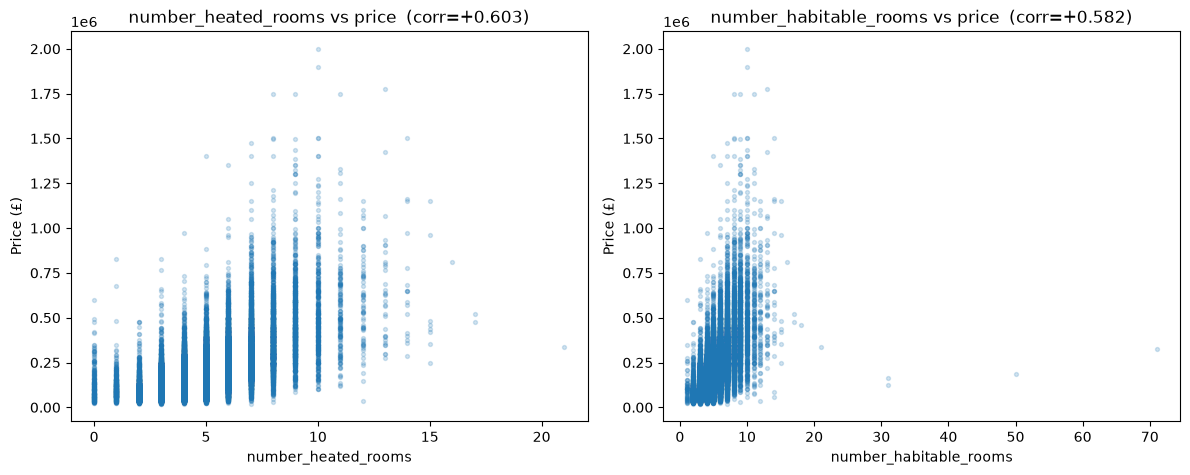

In [7]:
top2 = corrs.abs().sort_values(ascending=False).head(2).index.tolist()
fig, axes = plt.subplots(1, len(top2), figsize=(6 * len(top2), 5))
if len(top2) == 1:
    axes = [axes]
for ax, col in zip(axes, top2):
    ax.scatter(df[col], df["price"], alpha=0.2, s=8)
    ax.set_xlabel(col)
    ax.set_ylabel("Price (£)")
    ax.set_title(f"{col} vs price  (corr={corrs[col]:+.3f})")
plt.tight_layout()
plt.show()


## Summary: what this says about the Phase 2 feature list

Compare against the King County-derived guesses in the plan's Part 1 and
Part 3 ("condition proxies... parked until the simple model underperforms").
This is the evidence to either confirm or revise those guesses **before**
spending Phase 2 effort building features that turn out not to matter.


In [8]:
print("Numeric fields, strongest to weakest:")
print(corrs)


Numeric fields, strongest to weakest:
number_heated_rooms            0.603040
number_habitable_rooms         0.581792
total_floor_area               0.551465
co2_emissions_current          0.314912
extension_count                0.237369
number_open_fireplaces         0.114312
current_energy_efficiency      0.069393
potential_energy_efficiency   -0.033137
multi_glaze_proportion        -0.003303
Name: log_price, dtype: float64
